# 04. Initial data description: `ami_meter_residential `

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents) if (p / "bms_sa_review").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate the CICCADA repository root from {_current}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from bms_sa_review.synthetic_ami_creation.config import ami_config as Config
from bms_sa_review.synthetic_ami_creation.lib import ami_plots as Plots

sns.set_theme(style="ticks", context="notebook")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [21]:
# Validated palette (see the `dataviz` skill): fixed categorical hue order
# (8 hues, CVD-checked adjacent ordering), a dedicated neutral for "Other",
# and a single blue sequential ramp for every magnitude encoding below --
# never a rainbow, never color re-used to mean two different things.
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
OTHER_COLOR = "#9a9a94"
SEQUENTIAL_HEX = ["#cde2fb", "#86b6ef", "#3987e5", "#2a78d6", "#1c5cab", "#0d366b"]
SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQUENTIAL_HEX)
ACCENT = CATEGORICAL[0]

con = duckdb.connect()
con.sql(f"""
    CREATE OR REPLACE VIEW ami_meter AS
    SELECT * FROM read_parquet(
        '{Config.store_path("ami_meter").as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
""")

con.sql(f"""
    CREATE OR REPLACE VIEW ami_site_metadata AS
    SELECT * FROM read_parquet('{Config.store_path("ami_site_metadata").as_posix()}')
""")

con.sql(f"""
    CREATE OR REPLACE VIEW ami_meter_residential AS
    SELECT * FROM read_parquet(
        '{Config.store_path("ami_meter_residential").as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
""")

# ami_site_metadata_residential comes straight from notebook 03's own output
# file -- NOT rebuilt here from the raw ami_site_metadata -- because notebook
# 03 already did the residential-scope filter AND the DNSP/manufacturer ->
# key-mapping replacement. Reconstructing this view from ami_site_metadata
# would silently discard that remapping and bring the real DNSP/manufacturer
# names back.
con.sql(f"""
    CREATE OR REPLACE VIEW ami_site_metadata_residential AS
    SELECT * FROM read_parquet('{Config.store_path("ami_site_metadata_residential").as_posix()}')
""")

## 1. Fleet overview


## 1.1. Fleet

In [22]:
n_sites_metadata = con.sql("SELECT count(*) FROM ami_site_metadata").fetchone()[0]
n_sites_clean = con.sql("SELECT count(*) FROM ami_site_metadata_residential").fetchone()[0]
n_rows_raw_meter = con.sql("SELECT count(*) FROM ami_meter").fetchone()[0]
n_rows_meter_clean = con.sql(f"""
    SELECT count(*) FROM read_parquet(
        '{Config.store_path("ami_meter_clean").as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
""").fetchone()[0]
n_rows_residential = con.sql("SELECT count(*) FROM ami_meter_residential").fetchone()[0]

print(f"{n_sites_metadata:,} sites total in ami_site_metadata.")
print(f"{n_sites_clean:,} of those are residential-scoped sites with at least one row "
      f"in ami_meter_residential -- this is the site scope for every section below.")
print(f"\nami_meter:             {n_rows_raw_meter:,} rows")
print(f"ami_meter_clean:       {n_rows_meter_clean:,} rows "
      f"({1 - n_rows_meter_clean / n_rows_raw_meter:.4%} removed by notebook 01's hard checks)")
print(f"ami_meter_residential: {n_rows_residential:,} rows "
      f"({1 - n_rows_residential / n_rows_meter_clean:.4%} further removed by notebook 03's "
      f"residential-scope filter)")

10,562 sites total in ami_site_metadata.
10,307 of those are residential-scoped sites with at least one row in ami_meter_residential -- this is the site scope for every section below.

ami_meter:             1,492,262,979 rows
ami_meter_clean:       1,492,216,194 rows (0.0031% removed by notebook 01's hard checks)
ami_meter_residential: 1,478,042,928 rows (0.9498% further removed by notebook 03's residential-scope filter)


## 1.2. Metadata

In [20]:
con.sql("""
-- See the table's columns
DESCRIBE ami_site_metadata_residential;

-- See a few sample rows
SELECT *
FROM ami_site_metadata_residential
LIMIT 10;
""")

┌───────────┬─────────┬──────────┬───────────┬──────────┬───────────┬────────────────┬────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────┬─────────────────────┬──────────────┬─────────────┬──────────────────────┬───────────────┬─────────────┬───────────┬─────────────────────┬─────────────────────┬────────────┬──────────────┬──────────────────────────┐
│  site_id  │  state  │ postcode │ longitude │ latitude │ dnsp_name │ dc_capacity_kw │ ac_capacity_kw │ ac_capacity_kw_json │ export_limit_kw │  monitoring_start   │ inverter_count │   pv_install_date   │ manufacturer │    model    │ flex_export_detected │ n_load_phases │ n_pv_phases │   s_99    │     first_seen      │      last_seen      │ in_ami_raw │ in_ami_meter │ in_ami_raw_phaseseparate │
│   int64   │ varchar │  int32   │  double   │  double  │  varchar  │     double     │     double     │       varchar       │     double      │      timestamp      │     double     │      timestamp      │

# 2. Geo distribution

11 DNSPs exceed 100 sites -- more than the 8 reliably distinguishable colors available. Showing only the top 8 by site count individually; the rest (each still >100 sites) fold into 'Other' too -- see the full table below for their real counts.
Full breakdown, all 17 DNSPs (ami_meter_clean scope):


,dnsp_name,n_sites
0,DNSP_13,"2,647"
1,DNSP_15,"1,840"
2,DNSP_8,"1,629"
3,DNSP_16,"1,080"
4,DNSP_2,"1,004"
5,DNSP_5,839
6,None,248
7,DNSP_11,237
8,DNSP_10,213
9,DNSP_14,198


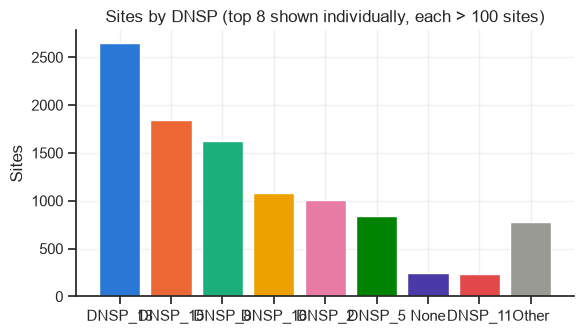

In [24]:
DNSP_MIN_SITES = 100

dnsp_counts = con.sql("""
    SELECT COALESCE(dnsp_name, 'Unknown') AS dnsp_name, count(*) AS n_sites
    FROM ami_site_metadata_residential GROUP BY COALESCE(dnsp_name, 'Unknown') ORDER BY n_sites DESC
""").df()

# dnsp_counts is already sorted by n_sites desc, so this preserves rank order.
candidates = dnsp_counts.loc[dnsp_counts.n_sites > DNSP_MIN_SITES, "dnsp_name"].tolist()
if len(candidates) > len(CATEGORICAL):
    print(f"{len(candidates)} DNSPs exceed {DNSP_MIN_SITES} sites -- more than the "
          f"{len(CATEGORICAL)} reliably distinguishable colors available. Showing only "
          f"the top {len(CATEGORICAL)} by site count individually; the rest (each still "
          f">{DNSP_MIN_SITES} sites) fold into 'Other' too -- see the full table below "
          "for their real counts.")
big_dnsp = candidates[:len(CATEGORICAL)]

dnsp_counts["dnsp_group"] = dnsp_counts.dnsp_name.where(dnsp_counts.dnsp_name.isin(big_dnsp), "Other")
dnsp_order = big_dnsp + (["Other"] if (~dnsp_counts.dnsp_name.isin(big_dnsp)).any() else [])

dnsp_palette = dict(zip(big_dnsp, CATEGORICAL[:len(big_dnsp)]))
if "Other" in dnsp_order:
    dnsp_palette["Other"] = OTHER_COLOR

grouped_counts = dnsp_counts.groupby("dnsp_group", as_index=False).n_sites.sum()
grouped_counts["dnsp_group"] = pd.Categorical(grouped_counts.dnsp_group, categories=dnsp_order, ordered=True)
grouped_counts = grouped_counts.sort_values("dnsp_group")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(grouped_counts.dnsp_group.astype(str), grouped_counts.n_sites,
       color=[dnsp_palette[d] for d in grouped_counts.dnsp_group])
ax.set_ylabel("Sites")
ax.set_title(f"Sites by DNSP (top {len(big_dnsp)} shown individually, each > {DNSP_MIN_SITES} sites)")
sns.despine(ax=ax)
fig.tight_layout()

print(f"Full breakdown, all {len(dnsp_counts)} DNSPs (ami_meter_clean scope):")
dnsp_counts[["dnsp_name", "n_sites"]].style.format({"n_sites": "{:,}"})

In [25]:
full_range = con.sql("""
    SELECT
      min(V) AS V_min, max(V) AS V_max,
      min(P_kw) AS P_kw_min, max(P_kw) AS P_kw_max,
      min(Q_kvar) AS Q_kvar_min, max(Q_kvar) AS Q_kvar_max
    FROM ami_meter_residential
""").df()

sample = con.sql("SELECT t_stamp, year, month, V, P_kw, Q_kvar FROM ami_meter_residential USING SAMPLE 2000000 ROWS").df()

summary_table = pd.DataFrame({
    "min": [full_range.V_min[0], full_range.P_kw_min[0], full_range.Q_kvar_min[0]],
    "max": [full_range.V_max[0], full_range.P_kw_max[0], full_range.Q_kvar_max[0]],
    "mean (sample)": [sample.V.mean(), sample.P_kw.mean(), sample.Q_kvar.mean()],
    "median (sample)": [sample.V.median(), sample.P_kw.median(), sample.Q_kvar.median()],
}, index=["V", "P_kw", "Q_kvar"])
summary_table.style.format("{:.3f}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min,max,mean (sample),median (sample)
V,0.100,297.690,240.739,241.000
P_kw,-368.317,798.128,-0.013,0.158
Q_kvar,-227.337,3119.593,-0.005,-0.119


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,share_at_or_below_vvar_v1,share_at_or_above_vw_v1,share_at_or_above_vvar_v4
0,0.0256%,0.2843%,0.0067%


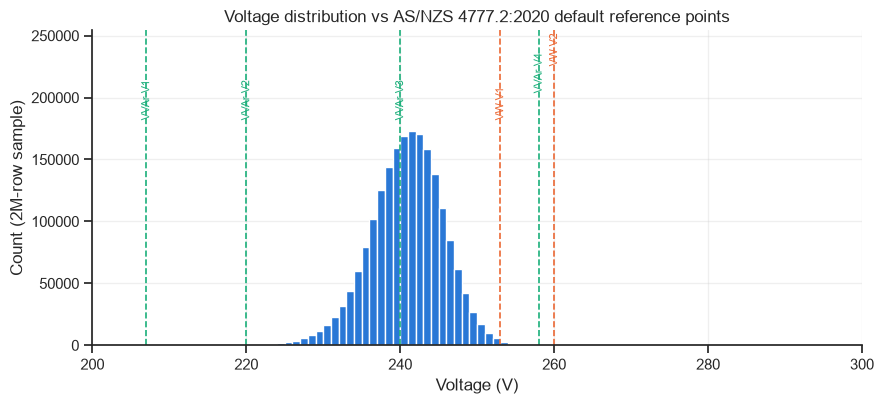

In [26]:
# AS/NZS 4777.2:2020 Australia A default set-points
AS4777 = {
    # Volt-Watt: 100% S_rated at/below V1, ramp to 20% at V2
    "VW": {"V1": 253.0, "V2": 260.0},
    # Volt-VAr: +Q1 supplying <=V1, 0 across deadband V2..V3, -Q4 absorbing >=V4
    "VVAR": {"V1": 207.0, "V2": 220.0, "V3": 240.0, "V4": 258.0},
}
vw_color, vvar_color = CATEGORICAL[1], CATEGORICAL[2]
threshold_lines = [
    ("VVAr V1", AS4777["VVAR"]["V1"], vvar_color, 1.00),
    ("VVAr V2", AS4777["VVAR"]["V2"], vvar_color, 1.00),
    ("VVAr V3", AS4777["VVAR"]["V3"], vvar_color, 1.00),
    ("VW V1",   AS4777["VW"]["V1"],   vw_color,   1.00),
    ("VVAr V4", AS4777["VVAR"]["V4"], vvar_color, 1.12),
    ("VW V2",   AS4777["VW"]["V2"],   vw_color,   1.24),
]

v_sample = sample.V.dropna()
v_sample = v_sample[(v_sample >= 200) & (v_sample <= 300)]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(v_sample, bins=100, range=(200, 300), color=ACCENT)
ymax = ax.get_ylim()[1]
for label, v, color, height_mult in threshold_lines:
    ax.axvline(v, color=color, linestyle="--", linewidth=1.2)
    ax.text(v, ymax * height_mult, label, color=color, rotation=90,
            ha="center", va="bottom", fontsize=8, clip_on=False)
ax.set_ylim(top=ymax * 1.4)
ax.set_xlim(200, 300)
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Count (2M-row sample)")
ax.set_title("Voltage distribution vs AS/NZS 4777.2:2020 default reference points")
sns.despine(ax=ax)
fig.tight_layout()

exposure = con.sql(f"""
    SELECT
      avg(CASE WHEN V <= {AS4777["VVAR"]["V1"]} THEN 1.0 ELSE 0.0 END) AS share_at_or_below_vvar_v1,
      avg(CASE WHEN V >= {AS4777["VW"]["V1"]} THEN 1.0 ELSE 0.0 END) AS share_at_or_above_vw_v1,
      avg(CASE WHEN V >= {AS4777["VVAR"]["V4"]} THEN 1.0 ELSE 0.0 END) AS share_at_or_above_vvar_v4
    FROM ami_meter_residential WHERE V IS NOT NULL
""").df()
exposure.style.format("{:.4%}")


10,307 of 10,307 sites have a non-null pv_install_date.
10,307 of those also have a non-null ac_capacity_kw.


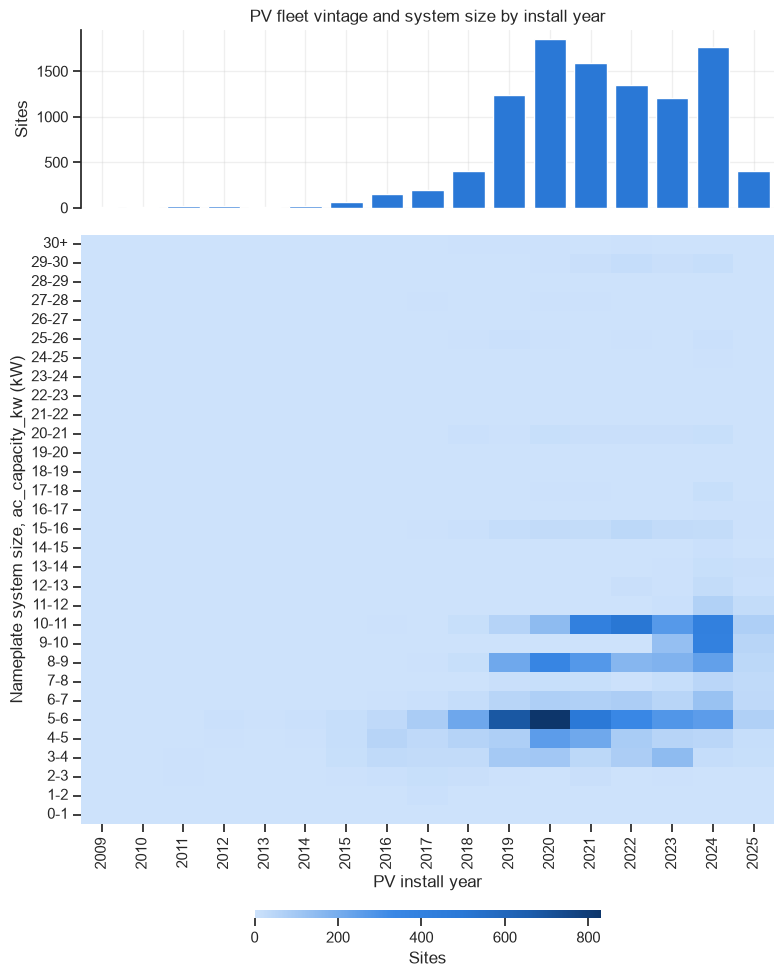

In [27]:
install_dates = con.sql("""
    SELECT pv_install_date, ac_capacity_kw
    FROM ami_site_metadata_residential WHERE pv_install_date IS NOT NULL
""").df()
install_dates["install_year"] = pd.to_datetime(install_dates.pv_install_date).dt.year

# System size buckets: 1kW-wide from 0 to 30kW, then a single 30kW+ aggregate.
BUCKET_EDGES = list(range(0, 31, 1))
bucket_labels = [f"{lo}-{lo + 1}" for lo in BUCKET_EDGES[:-1]] + ["30+"]
install_dates["size_bucket"] = pd.cut(
    install_dates.ac_capacity_kw, bins=BUCKET_EDGES + [float("inf")],
    labels=bucket_labels, right=False, include_lowest=True,
)

# Both panels must show the exact same set of years, in the same order, on
# the same x positions -- computed once here rather than left to each
# panel's own groupby, since a year could otherwise appear in one panel but
# not the other (e.g. every install in a year happens to have a null
# ac_capacity_kw, which pd.cut turns into NaN and groupby then drops).
ALL_YEARS = sorted(install_dates.install_year.unique())

by_year = (
    install_dates.groupby("install_year").size()
    .reindex(ALL_YEARS, fill_value=0)
)

# Rows = size bucket, columns = install year, cells = site count -- built as a
# full cross-tab (not just the combinations that happen to occur) so an
# empty year/bucket combination shows as zero, not a missing column/row.
size_by_year = (
    install_dates.groupby(["size_bucket", "install_year"], observed=False)
    .size()
    .reset_index(name="n_sites")
    .pivot(index="size_bucket", columns="install_year", values="n_sites")
    .reindex(index=bucket_labels, columns=ALL_YEARS, fill_value=0)
    .astype(int)
)

# height_ratios controls the relative height of the two panels -- raised
# from [1, 2] to [1, 4] to shrink the bar chart and grow the heatmap.
fig, (ax_year, ax_size) = plt.subplots(
    2, 1, figsize=(8, 10), gridspec_kw={"height_ratios": [1, 4]}, sharex=True,
)

# Bar chart plotted on the same integer x positions the heatmap columns will
# occupy (seaborn centres heatmap column i at i + 0.5), rather than on the
# year labels themselves -- this is what actually makes `sharex` line the
# two panels' columns up, not just their axis ranges.
x_pos = [i + 0.5 for i in range(len(ALL_YEARS))]
ax_year.bar(x_pos, by_year.values, width=0.8, color=ACCENT)
ax_year.set_ylabel("Sites")
ax_year.set_title("PV fleet vintage and system size by install year")
sns.despine(ax=ax_year, bottom=True)
ax_year.tick_params(axis="x", bottom=False, labelbottom=False)

# `yticklabels=1` forces every size bucket to get a label -- seaborn's
# default ("auto") thins them out once there are this many rows.
# `pad`/`fraction` trimmed down from their earlier generous values: `pad`
# is the gap between the heatmap and the colorbar, `fraction` is the total
# vertical band reserved for pad + colorbar together, and both were larger
# than a slim colorbar actually needs, which is what left the whitespace.
sns.heatmap(
    size_by_year, cmap=SEQUENTIAL_CMAP, ax=ax_size, yticklabels=1,
    cbar_kws={
        "label": "Sites", "orientation": "horizontal", "location": "bottom",
        "pad": 0.12, "fraction": 0.05, "shrink": 0.5, "aspect": 40,
    },
)
ax_size.set_xlabel("PV install year")
ax_size.set_ylabel("Nameplate system size, ac_capacity_kw (kW)")
ax_size.set_xticklabels([str(y) for y in ALL_YEARS], rotation=90)
ax_size.invert_yaxis()  # smallest bucket at the bottom, largest at the top

fig.tight_layout()

print(f"{len(install_dates):,} of {n_sites_clean:,} sites have a non-null pv_install_date.")
print(f"{install_dates.ac_capacity_kw.notna().sum():,} of those also have a non-null ac_capacity_kw.")

In [28]:
phase_combo = con.sql("""
    SELECT n_load_phases, n_pv_phases, count(*) AS n_sites
    FROM ami_site_metadata_residential
    GROUP BY n_load_phases, n_pv_phases
    ORDER BY n_sites DESC
""").df()

pivot_phase = phase_combo.pivot_table(
    index="n_load_phases", columns="n_pv_phases", values="n_sites", fill_value=0
).astype(int)
pivot_phase.index = [f"{n} load phase(s)" for n in pivot_phase.index]
pivot_phase.columns = [f"{n} PV phase(s)" for n in pivot_phase.columns]
pivot_phase.style.format("{:,}")


,0 PV phase(s),1 PV phase(s),2 PV phase(s),3 PV phase(s)
1 load phase(s),108,"8,130",190,13
2 load phase(s),4,83,4,10
3 load phase(s),67,668,29,"1,001"


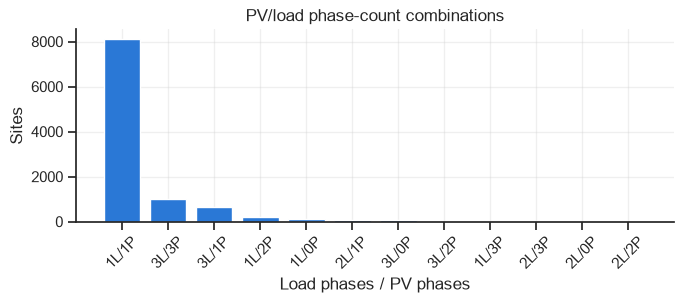

In [29]:
combo_labels = [f"{int(r.n_load_phases)}L/{int(r.n_pv_phases)}P" for _, r in phase_combo.iterrows()]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(combo_labels, phase_combo.n_sites, color=ACCENT)
ax.set_xlabel("Load phases / PV phases")
ax.set_ylabel("Sites")
ax.set_title("PV/load phase-count combinations")
ax.tick_params(axis="x", rotation=45)
sns.despine(ax=ax)
fig.tight_layout()


10,307 of 10,307 sites have both values. Pearson correlation: 0.942


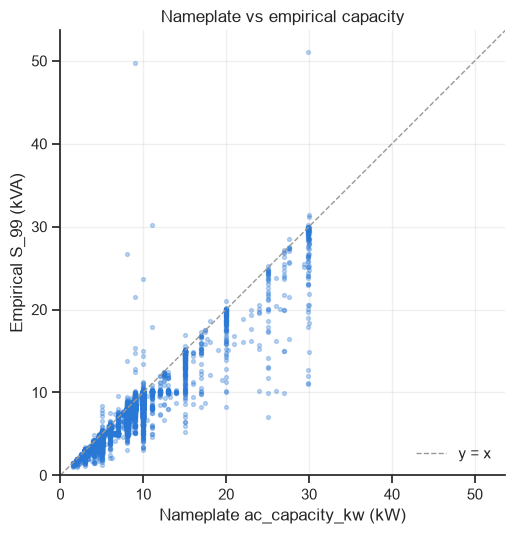

In [30]:
capacity = con.sql("""
    SELECT ac_capacity_kw, s_99
    FROM ami_site_metadata_residential
    WHERE ac_capacity_kw IS NOT NULL AND s_99 IS NOT NULL
""").df()

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(capacity.ac_capacity_kw, capacity.s_99, s=8, alpha=0.3, color=ACCENT)
lims = [0, max(capacity.ac_capacity_kw.max(), capacity.s_99.max()) * 1.05]
ax.plot(lims, lims, color=OTHER_COLOR, linestyle="--", linewidth=1, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Nameplate ac_capacity_kw (kW)")
ax.set_ylabel("Empirical S_99 (kVA)")
ax.set_title("Nameplate vs empirical capacity")
ax.set_aspect("equal")
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()

corr = capacity.ac_capacity_kw.corr(capacity.s_99)
print(f"{len(capacity):,} of {n_sites_clean:,} sites have both values. Pearson correlation: {corr:.3f}")


Full breakdown, all 38 manufacturers (ami_meter_clean scope):


,manufacturer,n_sites
0,M13,"3,336"
1,M39,"1,801"
2,M15,"1,549"
3,M10,"1,536"
4,M27,625
5,M32,537
6,M34,203
7,M37,191
8,M1,144
9,M18,97


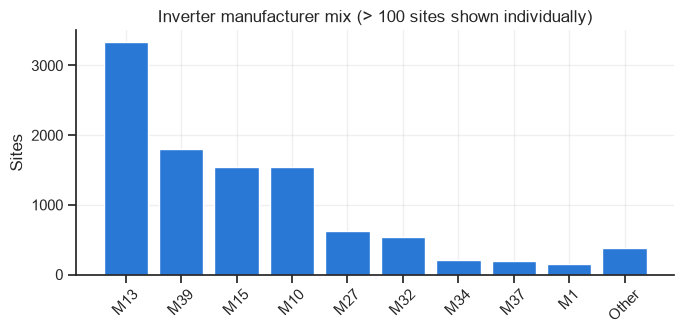

In [31]:
manufacturer_counts = con.sql("""
    SELECT manufacturer, count(*) AS n_sites
    FROM ami_site_metadata_residential
    WHERE manufacturer IS NOT NULL
    GROUP BY manufacturer ORDER BY n_sites DESC
""").df()

big_manufacturer = manufacturer_counts.loc[manufacturer_counts.n_sites > DNSP_MIN_SITES, "manufacturer"].tolist()
manufacturer_counts["manufacturer_group"] = manufacturer_counts.manufacturer.where(
    manufacturer_counts.manufacturer.isin(big_manufacturer), "Other"
)
manufacturer_order = big_manufacturer + (
    ["Other"] if (~manufacturer_counts.manufacturer.isin(big_manufacturer)).any() else []
)
grouped_manufacturer = manufacturer_counts.groupby("manufacturer_group", as_index=False).n_sites.sum()
grouped_manufacturer["manufacturer_group"] = pd.Categorical(
    grouped_manufacturer.manufacturer_group, categories=manufacturer_order, ordered=True
)
grouped_manufacturer = grouped_manufacturer.sort_values("manufacturer_group")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(grouped_manufacturer.manufacturer_group.astype(str), grouped_manufacturer.n_sites, color=ACCENT)
ax.set_ylabel("Sites")
ax.set_title(f"Inverter manufacturer mix (> {DNSP_MIN_SITES} sites shown individually)")
ax.tick_params(axis="x", rotation=45)
sns.despine(ax=ax)
fig.tight_layout()

print(f"Full breakdown, all {len(manufacturer_counts)} manufacturers (ami_meter_clean scope):")
manufacturer_counts[["manufacturer", "n_sites"]].style.format({"n_sites": "{:,}"})
